# Assignment 1 of the Intelligent Optimization and Problem Solving course regarding Randomized Optimization Algorithms (ROAs)
## Task
*In this assignment, you must develop two algorithms, i.e., one trajectory-based and one population-based, to solve the job shop scheduling problem. The problem, also known as the job-shop problem, involves scheduling a set of jobs on a set of machines, where each job consists of a sequence of operations that must be processed in a specific order (precedence constraints). The goal is typically to find the optimal sequence of jobs on each machine to minimize the makespan, i.e., the total time required to complete all jobs.*

In [17]:
# imports
import random
import math
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import copy
import itertools
import numpy as np

### Simmulated Annealing
#### Step 1: Parsing the Data

In [8]:
def parse_instance(filename, instance_name):
    """
    Parses a specific instance from jobshop.txt, handling headers and split lines robustly.
    """
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    all_numbers = []
    found_instance = False
    
    iterator = iter(lines)
    for line in iterator:
        stripped = line.strip()
        
        # 1. Find the start of the instance
        if not found_instance:
            if stripped == f"instance {instance_name}":
                found_instance = True
            continue
        
        # 2. Once found, stop if we hit the NEXT instance or a delimiter *after* getting data
        # (We check for data presence to ensure we don't break on the first header separator)
        if stripped.startswith("instance") and len(all_numbers) > 0:
            break
            
        # 3. Skip header lines (separators, descriptions)
        # We assume data lines start with a digit. 
        if not stripped or not stripped[0].isdigit():
            continue
            
        # 4. Collect all integers into a flat list
        # This handles cases where one job's data is split across multiple lines
        parts = list(map(int, stripped.split()))
        all_numbers.extend(parts)

    # Post-processing: Reconstruct the matrix
    if not all_numbers:
        return 0, 0, []
        
    num_jobs = all_numbers[0]
    num_machines = all_numbers[1]
    
    # The actual job data starts at index 2
    raw_data = all_numbers[2:]
    
    jobs_data = []
    current_idx = 0
    
    for _ in range(num_jobs):
        job_ops = []
        for _ in range(num_machines):
            # Each operation is a pair: (machine, time)
            if current_idx + 1 < len(raw_data):
                m_id = raw_data[current_idx]
                time = raw_data[current_idx+1]
                job_ops.append((m_id, time))
                current_idx += 2
        jobs_data.append(job_ops)
        
    return num_jobs, num_machines, jobs_data

# Example Usage
filename = 'jobshop_hackathon_instance_a.txt'
instance = 'hackathon'
num_jobs, num_machines, jobs_data = parse_instance(filename, instance)
print(f"Loaded {instance}: {num_jobs} Jobs, {num_machines} Machines")

# Validation: Check the first operation of the first job (Should be Machine 4, Time 88 based on your text)
if num_jobs > 0:
    print(f"First op of Job 0: {jobs_data[0][0]}")

Loaded hackathon: 20 Jobs, 20 Machines
First op of Job 0: (13, 47)


#### Step 2: Solution Representation

In [9]:
def generate_initial_solution(num_jobs, num_machines):
    """
    Generates a random operation-based permutation.
    e.g. for 2 jobs 2 machines: [0, 0, 1, 1] shuffled
    """
    solution = [job_id for job_id in range(num_jobs) for _ in range(num_machines)]
    random.shuffle(solution)
    return solution

def calculate_makespan(solution, jobs_data, num_jobs, num_machines):
    """
    Decodes the solution representation into a schedule and calculates makespan.
    """
    # Track when each machine is free
    machine_free_time = [0] * num_machines
    
    # Track when each job finishes its current operation
    job_next_free_time = [0] * num_jobs
    
    # Track which operation of the job we are currently processing
    job_op_index = [0] * num_jobs
    
    for job_id in solution:
        # Which operation is this for the job?
        op_idx = job_op_index[job_id]
        
        # Get machine and processing time for this operation
        machine_id, processing_time = jobs_data[job_id][op_idx]
        
        # The operation can start only when:
        # 1. The job is done with its previous step (job_next_free_time)
        # 2. The machine is free (machine_free_time)
        start_time = max(job_next_free_time[job_id], machine_free_time[machine_id])
        end_time = start_time + processing_time
        
        # Update trackers
        machine_free_time[machine_id] = end_time
        job_next_free_time[job_id] = end_time
        job_op_index[job_id] += 1
        
    return max(machine_free_time)

#### Step 3: Neighbor Operator

In [10]:
def get_neighbor(solution):
    """
    Swaps two random elements in the solution vector.
    Returns a new solution.
    """
    neighbor = copy.deepcopy(solution)
    idx1, idx2 = random.sample(range(len(solution)), 2)
    neighbor[idx1], neighbor[idx2] = neighbor[idx2], neighbor[idx1]
    return neighbor

#### Step 4: Simulated Annealing Loop

Starting 3 runs of Simulated Annealing...
Run 1 Best Makespan: 946
Run 2 Best Makespan: 937
Run 3 Best Makespan: 947
------------------------------
OVERALL BEST MAKESPAN: 937


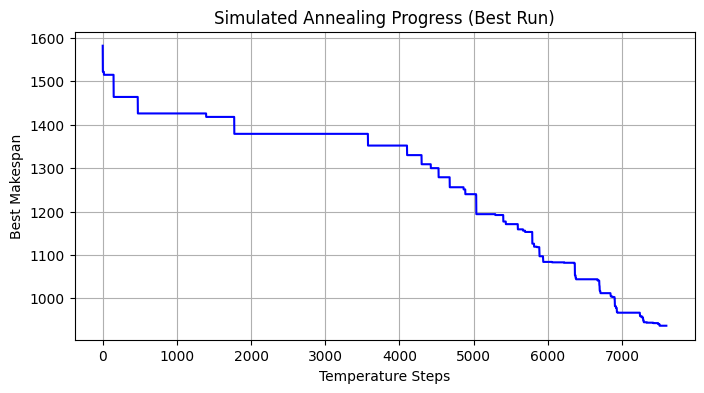

/tmp/ipykernel_8738/1238092773.py:95: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', num_jobs)


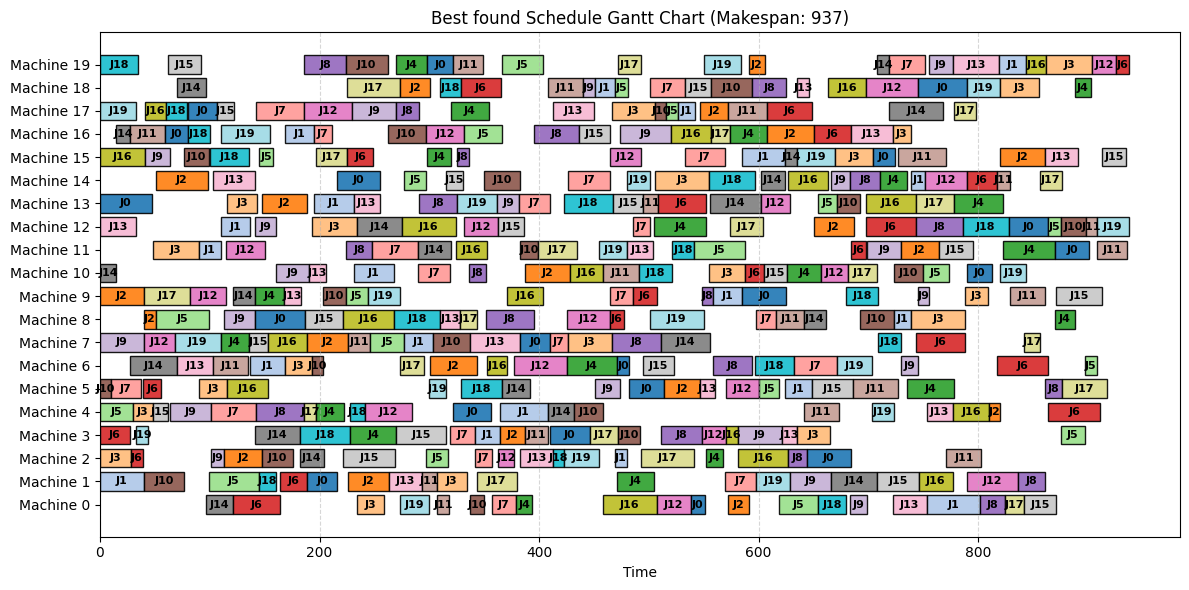

In [26]:
def simulated_annealing(jobs_data, num_jobs, num_machines, 
                        initial_temp=1000, cooling_rate=0.995, 
                        stopping_temp=0.001, max_iter_per_temp=100):
    
    # 1. Initialization
    current_solution = generate_initial_solution(num_jobs, num_machines)
    current_makespan = calculate_makespan(current_solution, jobs_data, num_jobs, num_machines)
    
    best_solution = current_solution
    best_makespan = current_makespan
    
    temperature = initial_temp
    history = [] # For plotting later
    
    # 2. Annealing Loop
    while temperature > stopping_temp:
        
        for _ in range(max_iter_per_temp):
            # Generate Neighbor
            neighbor = get_neighbor(current_solution)
            neighbor_makespan = calculate_makespan(neighbor, jobs_data, num_jobs, num_machines)
            
            # Calculate Delta
            delta = neighbor_makespan - current_makespan
            
            # Acceptance Probability
            if delta < 0:
                # Improvement: Always Accept
                current_solution = neighbor
                current_makespan = neighbor_makespan
                
                # Update Best Found
                if current_makespan < best_makespan:
                    best_makespan = current_makespan
                    best_solution = current_solution
            else:
                # Worsening: Accept with probability exp(-delta / T)
                if random.random() < math.exp(-delta / temperature):
                    current_solution = neighbor
                    current_makespan = neighbor_makespan
        
        history.append(best_makespan)
        # 3. Cooling
        temperature *= cooling_rate
        
    return best_solution, best_makespan, history

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random
import math

# --- NEW FUNCTIONS FOR GANTT CHART ---

def decode_solution(solution, jobs_data, num_jobs, num_machines):
    """
    Decodes the solution into a detailed schedule mapping exactly 
    when and where each job operation occurs.
    """
    machine_free_time = [0] * num_machines
    job_next_free_time = [0] * num_jobs
    job_op_index = [0] * num_jobs
    
    schedule = [] # Store dictionaries of each task
    
    for job_id in solution:
        op_idx = job_op_index[job_id]
        machine_id, processing_time = jobs_data[job_id][op_idx]
        
        start_time = max(job_next_free_time[job_id], machine_free_time[machine_id])
        end_time = start_time + processing_time
        
        # Save the scheduling details
        schedule.append({
            'Job': job_id,
            'Machine': machine_id,
            'Start': start_time,
            'Duration': processing_time
        })
        
        # Update trackers
        machine_free_time[machine_id] = end_time
        job_next_free_time[job_id] = end_time
        job_op_index[job_id] += 1
        
    return schedule

def plot_gantt_chart(schedule, makespan, num_machines):
    """
    Plots a Gantt chart using matplotlib based on the decoded schedule.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Generate distinct colors for the jobs
    cmap = plt.cm.get_cmap('tab20', num_jobs)
    colors = [cmap(i) for i in range(num_jobs)]
    
    for task in schedule:
        job = task['Job']
        machine = task['Machine']
        start = task['Start']
        duration = task['Duration']
        
        # Draw the bar
        ax.barh(y=machine, width=duration, left=start, 
                color=colors[job], edgecolor='black', alpha=0.9)
        
        # Add the Job ID text in the center of the bar
        ax.text(start + duration / 2, machine, f'J{job}', 
                ha='center', va='center', color='black', 
                fontsize=8, fontweight='bold')
        
    ax.set_yticks(range(num_machines))
    ax.set_yticklabels([f'Machine {i}' for i in range(num_machines)])
    ax.set_xlabel('Time')
    ax.set_title(f'Best found Schedule Gantt Chart (Makespan: {makespan})')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# --- EXECUTION ---

# Parameters
# Turning up the parameters to get the best results within the hackathon time limit.
# The SA algorithm outperforms ES in this implementation, so SA is the focus in the hackathon.
initial_temp = 2000
cooling_rate = 0.999
stopping_temp = 1
max_iter = 400

# Variables to track the overall best across all 10 runs
global_best_sol = None
global_best_score = float('inf')
global_best_history = []
no_runs = 3

print(f"Starting {no_runs} runs of Simulated Annealing...")

for i in range(no_runs):
    best_sol, best_score, history = simulated_annealing(
        jobs_data, num_jobs, num_machines,
        initial_temp=initial_temp,
        cooling_rate=cooling_rate,
        stopping_temp=stopping_temp,
        max_iter_per_temp=max_iter
    )
    
    print(f"Run {i+1} Best Makespan: {best_score}")
    
    # Update global best
    if best_score < global_best_score:
        global_best_score = best_score
        global_best_sol = best_sol
        global_best_history = history

print("-" * 30)
print(f"OVERALL BEST MAKESPAN: {global_best_score}")

# 1. Plot the convergence history of the best run
plt.figure(figsize=(8, 4))
plt.plot(global_best_history, color='blue')
plt.title("Simulated Annealing Progress (Best Run)")
plt.xlabel("Temperature Steps")
plt.ylabel("Best Makespan")
plt.grid(True)
plt.show()

# 2. Decode and Plot the Gantt chart for the best solution
best_schedule = decode_solution(global_best_sol, jobs_data, num_jobs, num_machines)
plot_gantt_chart(best_schedule, global_best_score, num_machines)

#### Step 5: Parameter tuning

In [13]:
def run_grid_search(jobs_data, num_jobs, num_machines, param_grid, num_runs=3):
    results = []
    
    # Generate all combinations of parameters
    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    print(f"Total configurations to test: {len(combinations)}")
    print("-" * 60)
    
    for i, params in enumerate(combinations):
        run_scores = []
        
        # Run the algorithm multiple times for stability
        for r in range(num_runs):
            # Pass the grid parameters to your SA function
            _, makespan, _ = simulated_annealing(
                jobs_data, 
                num_jobs, 
                num_machines,
                initial_temp=params['initial_temp'],
                cooling_rate=params['cooling_rate'],
                max_iter_per_temp=params['max_iter_per_temp'],
                stopping_temp=1 # Fix this low enough
            )
            run_scores.append(makespan)
        
        # Record stats
        avg_score = np.mean(run_scores)
        best_score = np.min(run_scores)
        
        results.append({
            'params': params,
            'avg_makespan': avg_score,
            'best_makespan': best_score
        })
        
        print(f"Config {i+1}: {params}")
        print(f"   -> Avg: {avg_score:.1f} | Best: {best_score}")
    
    # Sort results by best Average Makespan
    results.sort(key=lambda x: x['avg_makespan'])
    return results

# --- 1. Define your Grid ---
param_grid = {
    'initial_temp': [1000, 5000],
    'cooling_rate': [0.99, 0.995],
    'max_iter_per_temp': [100, 400]
}

# --- 2. Run the Search ---
print(f"Starting Grid Search on {instance}...")
sorted_results = run_grid_search(jobs_data, num_jobs, num_machines, param_grid, num_runs=5)

print("\nTop 3 Configurations:")
for res in sorted_results[:3]:
    print(res)

Starting Grid Search on hackathon...
Total configurations to test: 8
------------------------------------------------------------
Config 1: {'initial_temp': 1000, 'cooling_rate': 0.99, 'max_iter_per_temp': 100}
   -> Avg: 1041.4 | Best: 1016
Config 2: {'initial_temp': 1000, 'cooling_rate': 0.99, 'max_iter_per_temp': 400}
   -> Avg: 983.4 | Best: 964
Config 3: {'initial_temp': 1000, 'cooling_rate': 0.995, 'max_iter_per_temp': 100}
   -> Avg: 1023.0 | Best: 1015
Config 4: {'initial_temp': 1000, 'cooling_rate': 0.995, 'max_iter_per_temp': 400}
   -> Avg: 972.8 | Best: 965
Config 5: {'initial_temp': 5000, 'cooling_rate': 0.99, 'max_iter_per_temp': 100}
   -> Avg: 1030.2 | Best: 1008
Config 6: {'initial_temp': 5000, 'cooling_rate': 0.99, 'max_iter_per_temp': 400}
   -> Avg: 991.4 | Best: 984
Config 7: {'initial_temp': 5000, 'cooling_rate': 0.995, 'max_iter_per_temp': 100}
   -> Avg: 1010.0 | Best: 984
Config 8: {'initial_temp': 5000, 'cooling_rate': 0.995, 'max_iter_per_temp': 400}
   -> Av

### (μ,λ)-ES (Evolution Strategy)
Reusing already defined function "generate_initial_solution" and "calculate_makespan"

Starting (30, 200)-ES on loaded instance...
Gen 10: Best this gen: 1430 | Global Best: 1430
Gen 20: Best this gen: 1441 | Global Best: 1428
Gen 30: Best this gen: 1447 | Global Best: 1411
Gen 40: Best this gen: 1517 | Global Best: 1330
Gen 50: Best this gen: 1463 | Global Best: 1330
Gen 60: Best this gen: 1425 | Global Best: 1330
Gen 70: Best this gen: 1404 | Global Best: 1330
Gen 80: Best this gen: 1440 | Global Best: 1330
Gen 90: Best this gen: 1466 | Global Best: 1330
Gen 100: Best this gen: 1450 | Global Best: 1330
Gen 110: Best this gen: 1437 | Global Best: 1330
Gen 120: Best this gen: 1441 | Global Best: 1330
Gen 130: Best this gen: 1463 | Global Best: 1330
Gen 140: Best this gen: 1485 | Global Best: 1330
Gen 150: Best this gen: 1460 | Global Best: 1330
Gen 160: Best this gen: 1454 | Global Best: 1330
Gen 170: Best this gen: 1398 | Global Best: 1311
Gen 180: Best this gen: 1429 | Global Best: 1311
Gen 190: Best this gen: 1442 | Global Best: 1311
Gen 200: Best this gen: 1413 | Glo

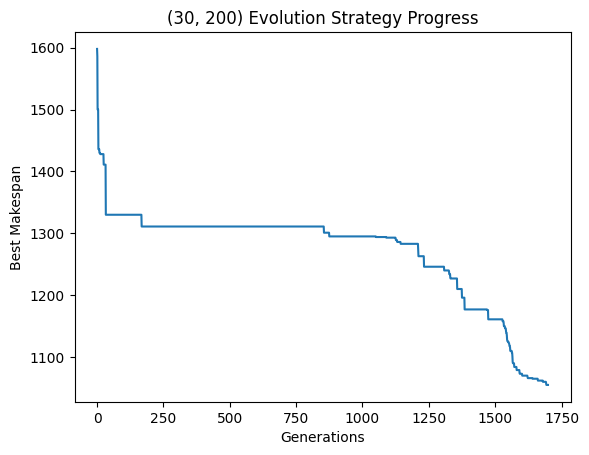

In [ ]:
def mutate(solution, num_swaps=1):
    """
    Applies mutation to a permutation solution.
    Swap mutation: picks two random positions and swaps them.
    Repeats num_swaps times.
    """
    neighbor = list(solution) # Make a copy
    length = len(neighbor)
    
    for _ in range(num_swaps):
        idx1, idx2 = random.sample(range(length), 2)
        neighbor[idx1], neighbor[idx2] = neighbor[idx2], neighbor[idx1]
        
    return neighbor

def es_lambda_mu(jobs_data, num_jobs, num_machines, 
                 mu=10, lambda_=50, generations=100, mutation_strength=1):
    """
    Executes a (mu, lambda) Evolution Strategy.
    """
    # 1. Initialize Population (mu parents)
    population = []
    for _ in range(mu):
        sol = generate_initial_solution(num_jobs, num_machines)
        score = calculate_makespan(sol, jobs_data, num_jobs, num_machines)
        population.append((sol, score))
    
    # Track the global best found so far (since parents die in (mu, lambda))
    # Sort to find initial best
    population.sort(key=lambda x: x[1])
    global_best_sol = population[0][0]
    global_best_score = population[0][1]
    
    history = []
    
    # 2. Evolution Loop
    for gen in range(generations):
        offspring_population = []
        
        # Generate lambda offspring
        for _ in range(lambda_):
            # 2a. Recombination/Selection: Pick one parent uniformly at random
            # (Standard ES often relies on mutation, so we pick random parents)
            parent_sol, _ = random.choice(population)
            
            # 2b. Mutation: Create child
            # Start with heavy mutation (exploration), end with single swaps (refinement)
            current_mutation_strength = max(1, int(mutation_strength * (1 - gen / generations)))y
            child_sol = mutate(parent_sol, num_swaps=current_mutation_strength)
            
            # 2c. Evaluation
            child_score = calculate_makespan(child_sol, jobs_data, num_jobs, num_machines)
            
            offspring_population.append((child_sol, child_score))
        
        # 3. Selection: (mu, lambda)
        # Select the best mu individuals strictly from the OFFSPRING
        offspring_population.sort(key=lambda x: x[1])
        population = offspring_population[:mu]
        
        # 4. Update Global Best (Elitism for final result tracking only)
        current_best_score = population[0][1]
        if current_best_score < global_best_score:
            global_best_score = current_best_score
            global_best_sol = population[0][0]
            
        history.append(global_best_score)
        
        # Optional: Print progress every 10 generations
        if (gen + 1) % 10 == 0:
            print(f"Gen {gen+1}: Best this gen: {current_best_score} | Global Best: {global_best_score}")

    return global_best_sol, global_best_score, history

# --- EXECUTION ---

# Parameters for (mu, lambda)
# Rule of thumb: lambda should be roughly 7x mu for good exploration/exploitation balance
mu = 30
lambda_ = 200
generations = 1700
mutation_strength = 20

print(f"Starting ({mu}, {lambda_})-ES on loaded instance...")

best_sol_es, best_score_es, history_es = es_lambda_mu(
    jobs_data, 
    num_jobs, 
    num_machines,
    mu=mu, 
    lambda_=lambda_, 
    generations=generations,
    mutation_strength=mutation_strength
)

print(f"Final Best Makespan (ES): {best_score_es}")

# Plotting
plt.plot(history_es)
plt.title(f"({mu}, {lambda_}) Evolution Strategy Progress")
plt.xlabel("Generations")
plt.ylabel("Best Makespan")
plt.show()

#### Parameter Tuning

In [14]:
def run_es_grid_search(jobs_data, num_jobs, num_machines, param_grid, num_runs=3):
    results = []
    
    # Generate all combinations
    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    print(f"Total configurations to test: {len(combinations)}")
    
    for i, params in enumerate(combinations):
        run_scores = []
        
        # Heuristic check: strictly enforce lambda > mu
        if params['lambda_'] <= params['mu']:
            continue
            
        for r in range(num_runs):
            # Run the ES
            _, best_score, _ = es_lambda_mu(
                jobs_data, 
                num_jobs, 
                num_machines,
                mu=params['mu'],
                lambda_=params['lambda_'],
                generations=params['generations'],
                mutation_strength=params['mutation_strength']
            )
            run_scores.append(best_score)
        
        avg_score = np.mean(run_scores)
        best_score = np.min(run_scores)
        
        results.append({
            'params': params,
            'avg_makespan': avg_score,
            'best_makespan': best_score
        })
        
        print(f"Config {i+1}: {params} -> Avg: {avg_score:.1f}")

    # Sort by best average performance
    results.sort(key=lambda x: x['avg_makespan'])
    return results

# --- Define the Grid ---
# Warning: ES is generally slower per generation than SA is per step.
# Keep generations lower for the grid search, then scale up for the final run.
es_param_grid = {
    'mu': [15, 30],
    'lambda_': [100, 200],        
    'mutation_strength': [10, 15, 20],  
    'generations': [1700]         
}

print("Starting ES Grid Search...")
es_results = run_es_grid_search(jobs_data, num_jobs, num_machines, es_param_grid, num_runs=5)

print("\nTop 3 ES Configurations:")
for res in es_results[:3]:
    print(res)

Starting ES Grid Search...
Total configurations to test: 12
Gen 10: Best this gen: 1484 | Global Best: 1436
Gen 20: Best this gen: 1411 | Global Best: 1407
Gen 30: Best this gen: 1395 | Global Best: 1395
Gen 40: Best this gen: 1329 | Global Best: 1329
Gen 50: Best this gen: 1368 | Global Best: 1329
Gen 60: Best this gen: 1411 | Global Best: 1329
Gen 70: Best this gen: 1380 | Global Best: 1329
Gen 80: Best this gen: 1390 | Global Best: 1320
Gen 90: Best this gen: 1422 | Global Best: 1320
Gen 100: Best this gen: 1447 | Global Best: 1320
Gen 110: Best this gen: 1401 | Global Best: 1320
Gen 120: Best this gen: 1445 | Global Best: 1320
Gen 130: Best this gen: 1361 | Global Best: 1320
Gen 140: Best this gen: 1366 | Global Best: 1320
Gen 150: Best this gen: 1360 | Global Best: 1320
Gen 160: Best this gen: 1397 | Global Best: 1320
Gen 170: Best this gen: 1379 | Global Best: 1320
Gen 180: Best this gen: 1379 | Global Best: 1319
Gen 190: Best this gen: 1350 | Global Best: 1319
Gen 200: Best this